# Feature Engineering — Validation

Each engineered feature should show separation between fraud and legitimate
classes. Features with no separation are candidates for removal.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/transactions_featured.csv', parse_dates=['timestamp'])

feature_cols = [
    'amount_vs_user_avg', 'amount_zscore', 'log_amount',
    'tx_count_1h', 'tx_count_24h', 'amount_sum_24h',
    'is_foreign_country', 'is_high_risk_country',
    'is_high_risk_mcc', 'is_night_tx', 'is_cnp',
]

print(f"Rows: {len(df):,}  |  Features: {len(feature_cols)}")
df[feature_cols + ['is_fraud']].head()

Rows: 100,000  |  Features: 11


,amount_vs_user_avg,amount_zscore,log_amount,tx_count_1h,tx_count_24h,amount_sum_24h,is_foreign_country,is_high_risk_country,is_high_risk_mcc,is_night_tx,is_cnp,is_fraud
0,0.758025,0.000000,3.646755,0.0,0.0,0.00,0,0,1,0,0,0
1,0.647214,0.000000,3.493169,0.0,0.0,0.00,0,0,0,1,0,0
2,1.125774,5.400431,4.033710,0.0,0.0,0.00,0,0,0,0,0,0
3,1.243080,1.594370,4.131159,0.0,1.0,55.47,1,1,0,0,0,0
4,1.185239,0.845555,4.084294,0.0,0.0,0.00,1,1,0,0,1,0


In [10]:
summary = df.groupby('is_fraud')[feature_cols].mean().T
summary.columns = ['Legitimate', 'Fraud']
summary['lift'] = (summary['Fraud'] / summary['Legitimate'].replace(0, np.nan)).round(2)
summary = summary.sort_values('lift', ascending=False)
print("📊 Feature means by class (lift = Fraud / Legitimate):\n")
print(summary.round(3))

📊 Feature means by class (lift = Fraud / Legitimate):

                      Legitimate   Fraud   lift
amount_zscore              0.232  17.067  73.62
amount_vs_user_avg         1.133   9.684   8.55
is_high_risk_country       0.068   0.288   4.26
is_foreign_country         0.073   0.294   4.01
is_cnp                     0.250   0.438   1.75
is_high_risk_mcc           0.301   0.478   1.59
log_amount                 3.551   4.710   1.33
is_night_tx                0.252   0.264   1.05
tx_count_24h               0.224   0.230   1.02
amount_sum_24h            13.441  12.856   0.96
tx_count_1h                0.010   0.008   0.89


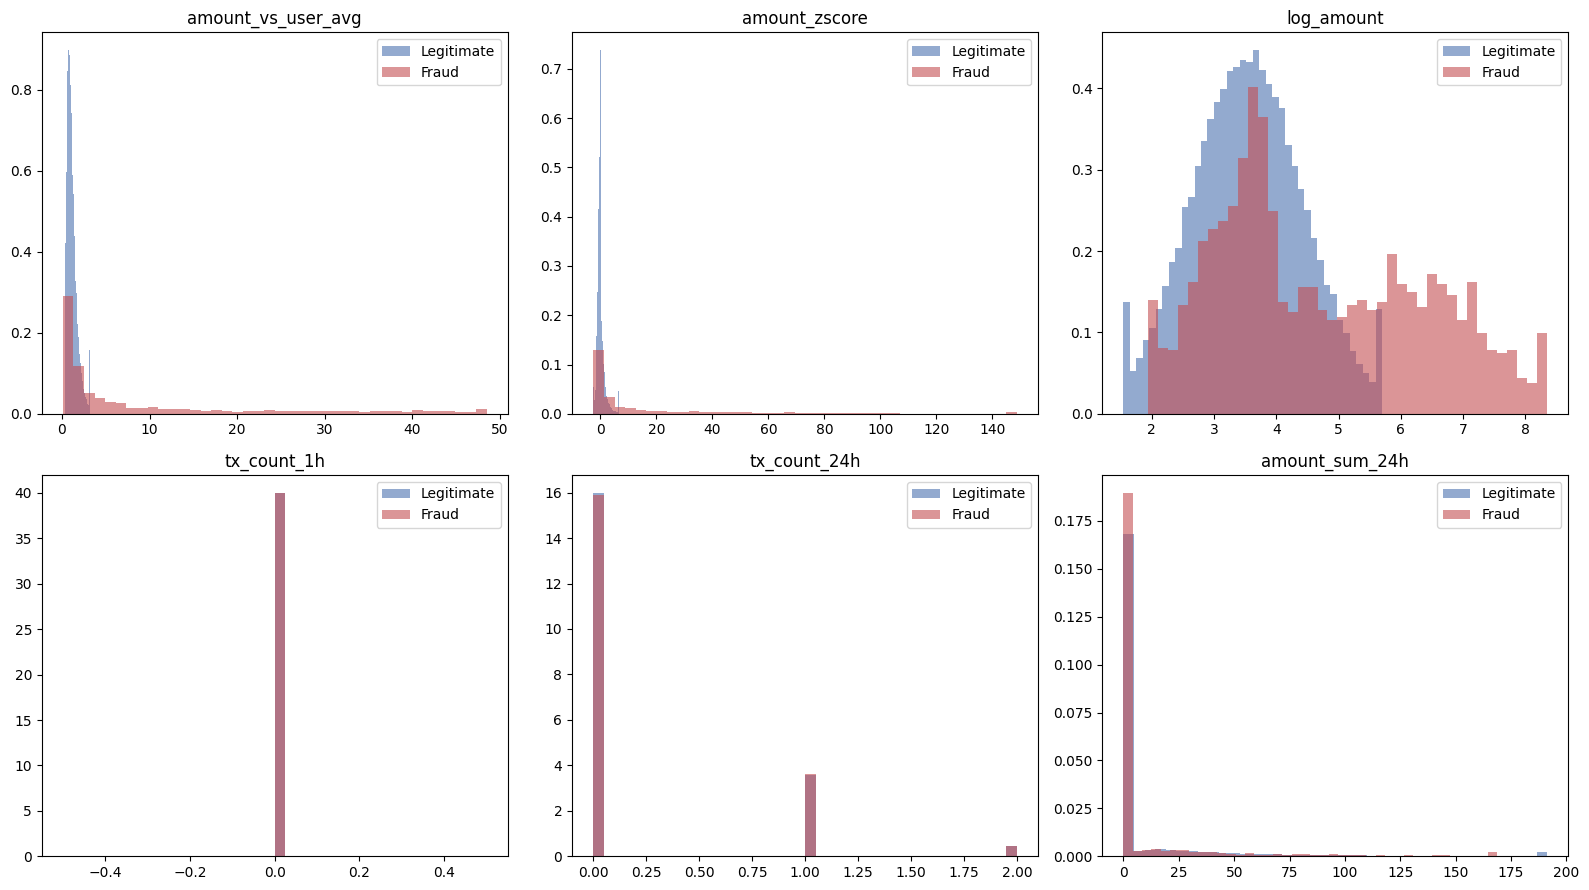

In [11]:
numeric_features = ['amount_vs_user_avg', 'amount_zscore', 'log_amount',
                    'tx_count_1h', 'tx_count_24h', 'amount_sum_24h']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flatten(), numeric_features):
    for label, color in [(0, '#4C72B0'), (1, '#C44E52')]:
        data = df[df['is_fraud'] == label][feat]
        # Clip extreme values for plotting only
        data = data.clip(data.quantile(0.01), data.quantile(0.99))
        ax.hist(data, bins=40, alpha=0.6,
                label='Fraud' if label else 'Legitimate',
                color=color, density=True)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

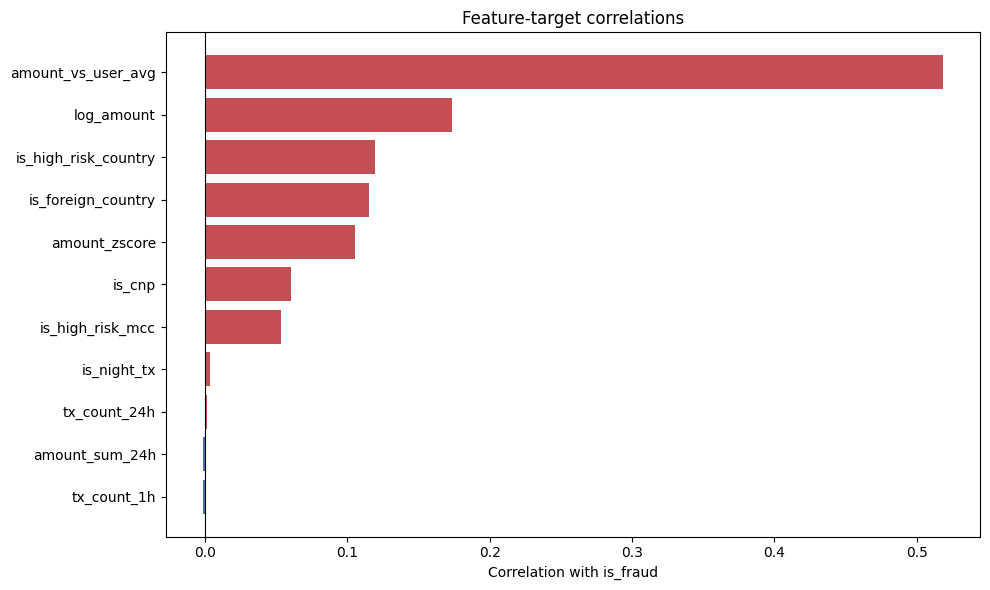


📌 Strongest positive signals:
amount_vs_user_avg      0.518
log_amount              0.173
is_high_risk_country    0.120
is_foreign_country      0.115
amount_zscore           0.106
Name: is_fraud, dtype: float64


In [12]:
correlations = df[feature_cols + ['is_fraud']].corr()['is_fraud'].drop('is_fraud').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with is_fraud')
plt.title('Feature-target correlations')
plt.tight_layout()
plt.show()

print("\n📌 Strongest positive signals:")
print(correlations.sort_values(ascending=False).head(5).round(3))